# RetailPulse AI Retail Analytics

## Notebook 5 : Demand Forecasting using Prophet

### Objectives

- Load cleaned retail dataset
- Prepare daily sales data
- Train Prophet forecasting model
- Predict next 30 days sales
- Visualize forecast
- Save predicted values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"]
    .sum()
    .reset_index()
)

daily_sales.head()

,InvoiceDate,TotalPrice
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [5]:
daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [6]:
print("Shape :", daily_sales.shape)

daily_sales.info()

Shape : (604, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      604 non-null    object 
 1   y       604 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.6+ KB


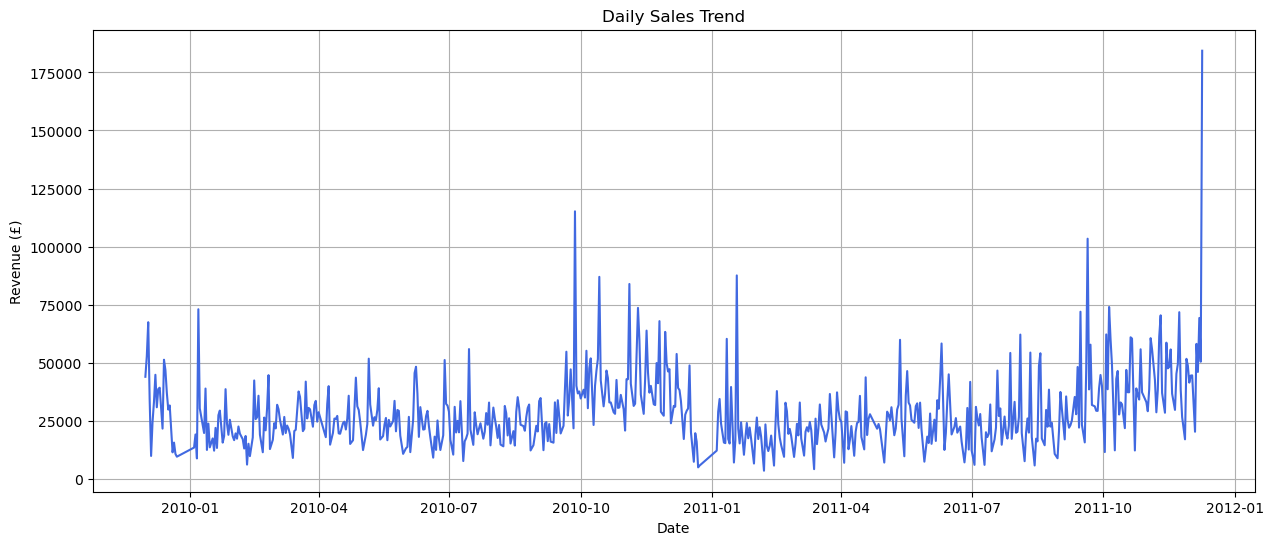

In [7]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"],
    color="royalblue"
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Revenue (£)")

plt.grid(True)

plt.show()

In [8]:
model = Prophet()

model.fit(daily_sales)

17:36:04 - cmdstanpy - INFO - Chain [1] start processing
17:36:05 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
model = Prophet()

model.fit(daily_sales)

17:36:18 - cmdstanpy - INFO - Chain [1] start processing
17:36:19 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=30)

future.tail()

,ds
629,2012-01-04
630,2012-01-05
631,2012-01-06
632,2012-01-07
633,2012-01-08


In [11]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,23366.346113,32711.521109,64446.683783,23366.346113,23366.346113,25945.697892,25945.697892,25945.697892,8263.268564,8263.268564,8263.268564,17682.429328,17682.429328,17682.429328,0.0,0.0,0.0,49312.044006
1,2009-12-02,23362.918625,31164.162350,62448.395598,23362.918625,23362.918625,22892.261038,22892.261038,22892.261038,5364.460059,5364.460059,5364.460059,17527.800979,17527.800979,17527.800979,0.0,0.0,0.0,46255.179662
2,2009-12-03,23359.491136,38716.961348,68709.798255,23359.491136,23359.491136,29838.081810,29838.081810,29838.081810,12589.557409,12589.557409,12589.557409,17248.524401,17248.524401,17248.524401,0.0,0.0,0.0,53197.572945
3,2009-12-04,23356.063647,28944.659760,57794.962526,23356.063647,23356.063647,20397.315568,20397.315568,20397.315568,3563.249747,3563.249747,3563.249747,16834.065822,16834.065822,16834.065822,0.0,0.0,0.0,43753.379215
4,2009-12-05,23352.636158,-5606.768370,24206.962896,23352.636158,23352.636158,-13190.713874,-13190.713874,-13190.713874,-29467.137379,-29467.137379,-29467.137379,16276.423505,16276.423505,16276.423505,0.0,0.0,0.0,10161.922284


In [12]:
forecast[
    ["ds",
     "yhat",
     "yhat_lower",
     "yhat_upper"]
].tail(30)

,ds,yhat,yhat_lower,yhat_upper
604,2011-12-10,9092.114663,-6908.576065,24177.738781
605,2011-12-11,31278.127698,14934.315258,47057.179939
606,2011-12-12,41419.028712,25525.542389,56979.833764
607,2011-12-13,42497.557403,27051.866660,58572.452934
608,2011-12-14,37970.480809,22473.201420,53588.865023
609,2011-12-15,43508.254090,28174.401913,59056.959413
610,2011-12-16,32759.353603,17390.288548,48363.189039
611,2011-12-17,-2003.650554,-17651.809182,13981.589454
612,2011-12-18,19796.242406,4718.958024,35355.029823
613,2011-12-19,29710.323255,14089.741912,45427.532876


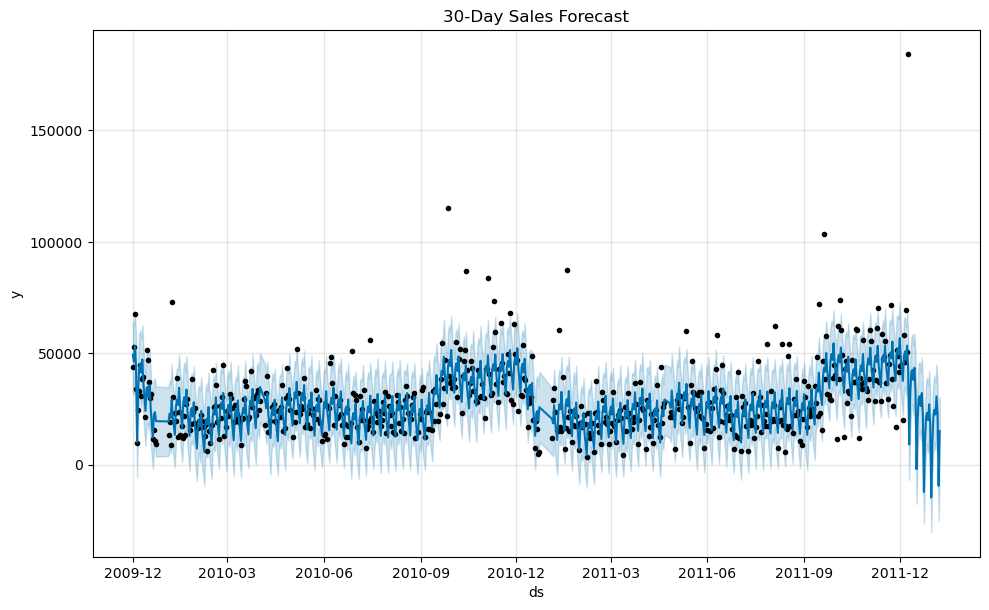

In [13]:
fig = model.plot(forecast)

plt.title("30-Day Sales Forecast")

plt.show()

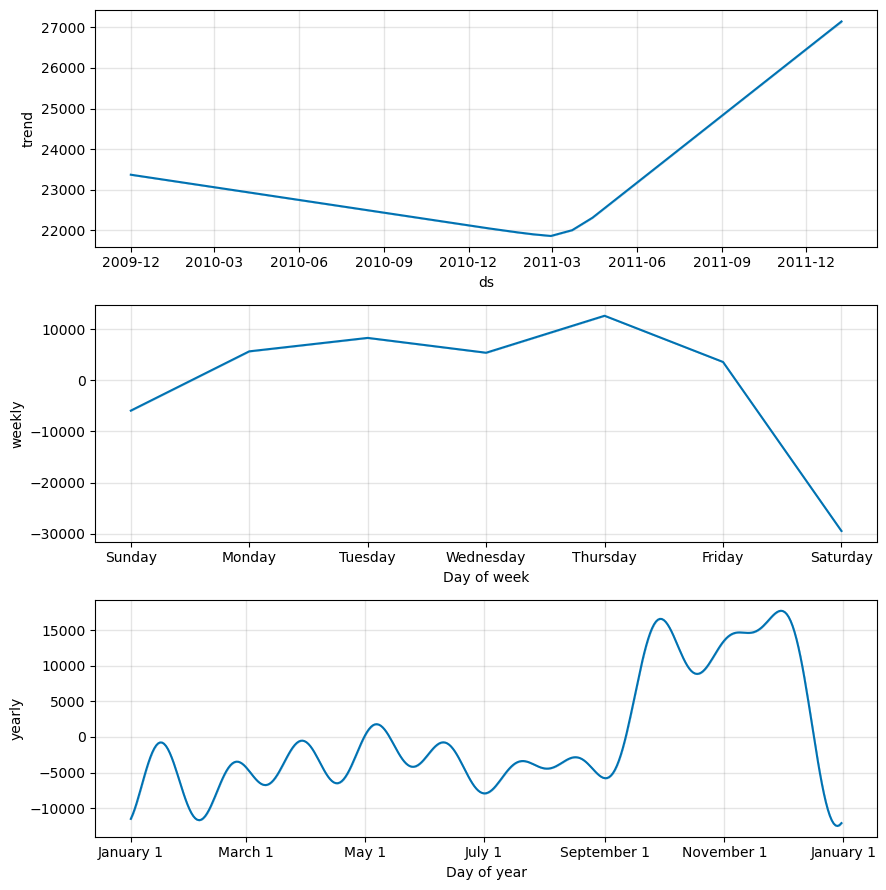

In [14]:
fig2 = model.plot_components(forecast)

plt.show()

In [15]:
forecast.to_csv(
    "../data/sales_forecast.csv",
    index=False
)

# Business Insights

The forecasting model predicts the expected sales for the next 30 days using historical sales data.

Key benefits include:

- Inventory planning
- Revenue estimation
- Demand forecasting
- Better business decision making
- Reduced stock shortages